# Weak Supervision


## Introduction

In this section, we apply what we learned in this chapter to implement **weak supervision**.
The idea behind weak supervision is that for each data point there is a latent true label that is inaccessible to us (even during training), instead we utilize weak signals from user-defined **labeling functions** (LF). The material here is an exposition and implementation of the **data programming** approach to weak supervision using LFs described in [@data-programming].

LFs can be thought of as heuristic rules that can be applied to a large subset of the data. In case the LF is not applicable, then the function simply abstains from making a prediction. Note that this is a realistic scenario, it's easier to describe rules than to manually annotate a large number of data. LFs provides noisy, less expensive labels, which can be useful in training noise-aware discriminative models. 

![**Weak supervision training pipeline**. The third image is flipped (i.e. the flow of prediction is right to left.) 
These two tasks will be implemented in this notebook. [Source](https://cs.brown.edu/people/sbach/files/bach-icml17-slides.pdf)](./img/01-weak-supervision-pipeline.png)

### Labeling Functions (LF)

Suppose we have a large corpus of IMDB movie reviews that we want to classify as positive or negative. Manually labeling thousands of reviews is expensive, but we can write heuristic rules called **labeling functions** (LF) that capture common patterns. Each LF inspects a review and returns `+1` (positive), `-1` (negative), or `0` (abstain). LFs can exploit many kinds of signals — word counts, explicit ratings, viewing behavior, or comparative language:

In [1]:
import re
import numpy as np
import torch
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

ds = load_dataset("imdb")
train_ds = ds["train"].shuffle(seed=RANDOM_SEED).select(range(3000))
train_texts = train_ds["text"]
y_train_imdb = np.array(train_ds["label"])  # {0, 1}

K = 2  # number of classes
ABSTAIN = K

Sample IMDB movie review (text) from the dataset:

In [2]:
print(y_train_imdb[0])
print("\n".join([train_texts[0][a: a + 80] for a in range(0, len(train_texts[0]), 80)]))

1
We always watch American movies with their particular accents from each region (
south, west, etc). We have the same here. All foreign people must to watch this 
movie and need to have a open mind to accept another culture, besides American a
nd European almost dominate the cinematographic industry.<br /><br />This movie 
tell us about a parallel world which it isn't figured even for those who live in
 a big city like São Paulo. All actors are improvising and they are very realist
ic. The camera give us an idea of their confuse world, the loneliness of each ch
aracter and invite us to share their world.<br /><br />It's a real great movie a
nd worst a rent even have it at home.


Example LFs for sentiment classification of IMDb reviews:

In [3]:
def lf_sentiment_words(text):
    text = text.lower()
    pos_count = sum(1 for w in ["great", "love", "amazing", "fun"] if w in text)
    neg_count = sum(1 for w in ["bad", "waste", "boring", "stupid"] if w in text)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN

def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN

def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower:
        return 0
    return ABSTAIN

Consider these example reviews and notice how each LF can be fooled or simply silent:

In [4]:
review = "I've watched this twice already and couldn't stop watching — the pacing is superb."

print("lf_sentiment_words      ", lf_sentiment_words(review))    # abstain (2) — no lexicon words match
print("lf_viewing_experience   ", lf_viewing_experience(review)) # positive (1) — "couldn't stop watching" signals engagement

lf_sentiment_words       2
lf_viewing_experience    1


In [5]:
review = "An excellent way to waste your Friday night — worse than anything I've seen this year."

print("lf_sentiment_words      ", lf_sentiment_words(review))    # negative (0) — "waste" fires
print("lf_comparative_sentiment", lf_comparative_sentiment(review)) # negative (0) — "worse than"

lf_sentiment_words       0
lf_comparative_sentiment 0


In [6]:
review = """
This movie is an absolute DISASTER. Two hours of my life I'll never get back.
The plot makes zero sense, the acting is wooden, and the dialogue sounds like
it was written by a toddler. Every scene drags on forever. I've seen better
cinematography in a high school project. The sound mixing is atrocious — I
couldn't finish it. Zero stars.
"""

print("lf_sentiment_words      ", lf_sentiment_words(review))    # abstain (2) — no lexicon word dominates
print("lf_viewing_experience   ", lf_viewing_experience(review)) # negative (0) — "couldn't finish" fires
print("lf_comparative_sentiment", lf_comparative_sentiment(review)) # abstain (2) — no comparative phrase present

lf_sentiment_words       2
lf_viewing_experience    0
lf_comparative_sentiment 2


### LF parameters

A labeling function is characterized by its **coverage** (fraction of inputs where it does not abstain) and **accuracy** (fraction correct among non-abstaining inputs). For the IMDB task, a full set of seven LFs has the following profile:

| LF | Coverage | Accuracy |
| :-: | :-: | :-: |
| `lf_strong_sentiment` | 0.41 | 0.88 |
| `lf_sentiment_words` | 0.69 | 0.76 |
| `lf_rating_mention` | 0.02 | 0.81 |
| `lf_viewing_experience` | 0.01 | 0.81 |
| `lf_comparative_sentiment` | 0.01 | 0.80 |
| `lf_recommendation` | 0.11 | 0.80 |
| `lf_exclamation_sentiment` | 0.05 | 0.81 |

[There is a natural trade-off:]{.underline} LFs with broad coverage (like `lf_sentiment_words`) tend to be less accurate, while highly accurate LFs fire on fewer reviews (`lf_strong_sentiment` is a massive exemption). The full definitions of these LFs and their application to IMDB data appear in the [application section](#application-imdb-movie-reviews) at the end of this notebook.

:::{.callout-note}
We generally do not have access to true labels for a representative sample of our dataset (or at best have access to a small labeled subset). Hence, even estimating the parameters of our LFs are not possible. The following sections will deal with algorithms for estimating these parameters as well as training a machine learning model with noisy labels.
:::

## Basic theory


For simplicity, we will limit our presentation to binary classification, although the method extends to the multiclass setting. For each data point $\textbf{\textsf{x}} \in \mathcal{X},$ the latent true label is $y \in \mathcal{Y} = \{0, 1, \ldots, K-1\}$. Suppose we have $N$ **labeling functions** $\lambda_j\colon \mathcal{X} \to \mathcal{Y} \cup \{-1\},$ where $-1$ denotes **abstention**. Given $M$ data points $\textbf{\textsf{x}}_i,$ we obtain an $M \times N$ matrix of LF outputs $\Lambda_{ij} = \lambda_j(\textbf{\textsf{x}}_i)$.

We write $\Lambda$ for the random variable representing LF outputs and $\lambda(\textbf{\textsf{x}})$ for the realized output vector of a specific input. Our first step is to estimate the joint distribution $p_\Phi(\Lambda, Y)$. We do MLE to find parameters $\hat{\Phi}$ that maximize the log-likelihood of the marginal 
$p_\Phi(\Lambda)$ of the observed LF outputs. See [below](/notebooks/tooling/10-weak-supervision.html#generative-model). This lets us calculate:

$$
\boxed{p_{\hat{\Phi}}(y \mid  \lambda(\textbf{\textsf{x}})) = \frac{p_{\hat{\Phi}}( y,\,  \lambda(\textbf{\textsf{x}}))}{p_{\hat{\Phi}}( \lambda(\textbf{\textsf{x}}))}}
$$ 

for any $y = 0, \ldots, K-1$ and any input $\textbf{\textsf{x}}.$ Given this, a **noise-aware** discriminative model $f_\Theta$ is trained by minimizing the ff. loss:

$$
\boxed{
    \mathcal{L}_{\text{clf}}(\Theta) = 
    \frac{1}{M}\sum_{i=1}^M \sum_{y=0}^{K-1} 
    \ell(f_\Theta(\textbf{\textsf{x}}_i), y) \cdot 
    {p_{\hat{\Phi}}(y \mid  \lambda(\textbf{\textsf{x}}_i))}
}
$$

where $\ell$ is the usual loss criterion. This looks like the usual loss, except we don't have a single label. All labels contribute weighted by the probability of the label given the LF outputs of the input.

### Generative model

For each LF $\lambda_j$, we learn a [confusion matrix](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html) $\mathbf{C}^{(j)} \in \mathbb{R}^{K \times (K+1)}$ where the rows correspond to the true class $y \in \{0, \ldots, K-1\}$ and the columns correspond to LF outputs $\lambda \in \{-1, 0, \ldots, K-1\}$ (column index $-1$ = abstain). Each entry $C^{(j)}_{y,\lambda}$ gives $p(\lambda_j \mid y)$ and each row sums to 1. We assume that LF outputs are **conditionally independent** given the true label. Hence,

$$
\begin{aligned}
p_\Phi(\lambda(\textbf{\textsf{x}})) 
&= \sum_{y=0}^{K-1} p_y \cdot \prod_{j=1}^N C^{(j)}_{y,\, \lambda_j(\textbf{\textsf{x}})}
\end{aligned}
$$

Our goal is to perform MLE on $\Phi = \{\mathbf{C}^{(1)}, \ldots, \mathbf{C}^{(N)}\}$ by minimizing:

$$
\mathcal{L}_{\text{gen}}(\Phi) = \sum_{i=1}^M -\log \left( 
    \sum_{y=0}^{K-1} p_y \cdot \prod_{j=1}^N C^{(j)}_{y,\, \Lambda_{ij}} 
\right).
$$


:::{.callout-note}
**Why model $p(\Lambda \mid Y)$ rather than $p(Y \mid \Lambda)$ directly?** Because the forward direction &mdash; how each LF behaves given a true label &mdash; is what we can decompose per-LF and estimate from unlabeled data. Each LF has its own confusion matrix independent of the others. Bayes' rule then gives us the posterior we actually need.
:::

Each LF has its own **confusion matrix** showing how its outputs relate to the true labels. For instance, `lf_sentiment_words` has asymmetric accuracy — it is much better at identifying positive reviews than negative ones:

In [ ]:
from sklearn.metrics import confusion_matrix as cm

outputs = np.array([lf_sentiment_words(t) for t in train_texts])
fired = outputs != ABSTAIN

labels_fired = y_train_imdb[fired]
preds_fired = outputs[fired]

confmat = cm(labels_fired, preds_fired, labels=[0, 1])
df = pd.DataFrame(confmat, index=["y=0 (neg)", "y=1 (pos)"], columns=["pred=0", "pred=1"])
df

,pred=0,pred=1
y=0 (neg),485,387
y=1 (pos),76,875


:::{.callout-tip}
In practice, LFs are **iteratively refined**: we inspect disagreements between LFs, compare against any available ground truth, and consult domain knowledge. Since LFs are user-defined heuristics, they require some expertise and data exploration to be effective.
:::

### Code implementation

We implement the confusion-matrix-based generative model. Each LF $j$ has a $K \times (K+1)$ confusion matrix $\mathbf{C}^{(j)}$. We store the non-abstain entries as logits and derive abstain probabilities via $1 - \sum$.

In [8]:
import torch
torch.manual_seed(1)

K = 2  # number of classes
n = 4  # number of LFs

# Example LF output matrix: values in {0, 1, ..., K} where K = abstain
L = torch.tensor([
    [0, K,  1,  1],
    [1, 0,  0,  K],
])

# Confusion matrix logits: shape (K, K, n) — non-abstain entries
# C_logits[y, k, j] is the unnormalized log-weight for P(λ_j = k | Y = y)
C_logits = torch.randn(K, K, n)

# Convert to probabilities via softmax-like normalization
# For each (y, j): we have K logits for classes 0..K-1
# p_class[y, k, j] = exp(logit) / (1 + sum(exp(logits)))  — abstain gets the residual
exp_logits = torch.exp(C_logits)                    # (K, K, n)
denom = 1 + exp_logits.sum(dim=1, keepdim=True)     # (K, 1, n)
p_class = exp_logits / denom                         # (K, K, n) — P(λ=k | y) for k in {0,...,K-1}
p_abstain = 1.0 / denom                             # (K, 1, n) — P(λ=K | y)

# Full confusion matrix: (K, K+1, n) — columns: [class 0, ..., class K-1, abstain]
C = torch.cat([p_class, p_abstain], dim=1)           # (K, K+1, n)
print("Confusion matrix shape:", C.shape)
print("Row sums (should be 1):", C.sum(dim=1))

Confusion matrix shape: torch.Size([2, 3, 4])
Row sums (should be 1): tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]])


We index into the confusion matrix using the LF output matrix. Class labels $\{0, \ldots, K-1\}$ map to the first $K$ columns, and abstain ($K$) maps to the last column. No remapping needed:

In [9]:
# P(L | y=1): for each instance i and LF j, look up C[y=1, L[i,j], j]
y = 1
C[y, L, torch.arange(n)]  # shape: (m, n)

tensor([[0.2141, 0.1289, 0.4626, 0.4731],
        [0.3495, 0.1746, 0.1692, 0.2964]])

The product across LFs gives the conditional likelihood of the observed LF outputs for a given true label:

In [10]:
# P(Λ_i | y) = prod_j C[y, Λ_{ij}, j]
for y in range(K):
    probs = C[y, L, torch.arange(n)]  # (m, n)
    print(f"P(Λ | y={y}):", probs.prod(dim=1))

P(Λ | y=0): tensor([0.0014, 0.0196])
P(Λ | y=1): tensor([0.0060, 0.0031])


The marginal probability of the LF outputs, summing over the latent label:

In [11]:
py = torch.tensor([0.5, 0.5])  # class prior

p_marginal = sum(
    py[y] * C[y, L, torch.arange(n)].prod(dim=1)
    for y in range(K)
)
p_marginal

tensor([0.0037, 0.0113])

Note that we generally have $M \gg 1$ terms with values in $[0, 1].$ So we use $\log$ to avoid underflow:

In [12]:
print("     p(Λ):", p_marginal.prod().item())
print("-log p(Λ):", -torch.log(p_marginal).sum().item())

     p(Λ): 4.230787817505188e-05
-log p(Λ): 10.070537567138672


## Experiments

In [13]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import random
import numpy as np
import pandas as pd

from notebooks.plot import set_format
set_format("svg")

RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = (
    torch.device("cuda:0") if torch.cuda.is_available() else (
        torch.device("mps") if torch.mps.is_available() else 
            torch.device("cpu")
    )
)

print(f"Using device: {DEVICE}")

Using device: mps


### Simulated LFs

Generating a toy dataset. Also setting the prior label probabilities:

In [14]:
m = 10000
K = 2
LABEL_PROBS = {0: 0.40, 1: 0.60}
y_true = np.random.choice([0, 1], size=m, p=[LABEL_PROBS[0], LABEL_PROBS[1]])

s = 2 * torch.pi * torch.rand(m, 1)
r = 0.5 * torch.tensor(y_true, dtype=torch.float32).view(-1, 1)  # 0 -> r=0, 1 -> r=0.5
x = torch.cat([r * torch.cos(s), r * torch.sin(s)], dim=1) + 0.05 * torch.randn(m, 2)

t = np.linspace(0, 2*np.pi, 100)
x0 = 0.5 * np.cos(t)
x1 = 0.5 * np.sin(t)
x_neg = x[torch.where(torch.tensor(y_true) == 0)]
x_pos = x[torch.where(torch.tensor(y_true) == 1)]

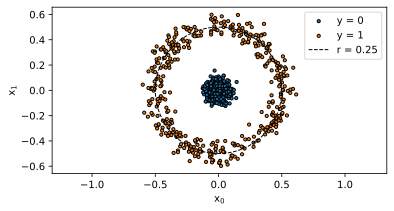

In [15]:
#| code-fold: true
def plot_dataset(x_neg, x_pos):
    m = len(x_neg)
    limit = m // 10
    plt.figure(figsize=(6, 3))
    plt.scatter(x_neg[:limit, 0], x_neg[:limit, 1], s=10.0, edgecolor="k", color="C0", label="y = 0")
    plt.scatter(x_pos[:limit, 0], x_pos[:limit, 1], s=10.0, edgecolor="k", color="C1", label="y = 1")
    plt.plot(x0, x1, color='black', linewidth=1, linestyle='dashed', label="r = 0.25")
    plt.xlabel("x$_0$")
    plt.ylabel("x$_1$")
    plt.legend()
    plt.axis("equal")

plot_dataset(x_neg, x_pos)

**Figure.** Below we use $r = 0.25$ as basis for synthetic LFs.

Note that radius less than 0.25 determines the label as $y = 0$ (with high probability):

In [16]:
# radius >= 0.25 -> class 1, else class 0
((torch.sqrt((x ** 2).sum(dim=1)) >= 0.25).long().numpy() == y_true).mean()

np.float64(1.0)

We use this to write simulated LFs with given parameters:

In [17]:
def lf_sim(coverage, accuracy):
    def predict(x):
        m = x.shape[0]
        y = (torch.sqrt((x ** 2).sum(dim=1)) >= 0.25).long()  # 0 or 1
        abstain_mask = torch.rand(m) >= coverage
        flip_mask = torch.rand(m) >= accuracy
        y[flip_mask] = 1 - y[flip_mask]  # flip label
        y[abstain_mask] = K               # abstain
        return y
    return predict

# example
p = lf_sim(0.3, 0.8)(x).numpy()
fired = p != K
print("cov: ", fired.mean())
print("acc: ", (p[fired] == y_true[fired]).mean())
print("acc (y=0):", (p[fired & (y_true == 0)] == y_true[fired & (y_true == 0)]).mean())
print("acc (y=1):", (p[fired & (y_true == 1)] == y_true[fired & (y_true == 1)]).mean())

cov:  0.2993
acc:  0.7945205479452054
acc (y=0): 0.7960848287112561
acc (y=1): 0.7934352009054896


Initializing the empirical LF matrix for display. Some LFs have fairly low accuracy:

In [18]:
lf_params = [(0.30, 0.75), (0.50, 0.65), (0.40, 0.70), (0.20, 0.80), (0.25, 0.90)]
labeling_funcs_raw = [lf_sim(*param) for param in lf_params]

df = pd.DataFrame({"y": y_true})
df["x0"] = x[:, 0].numpy()
df["x1"] = x[:, 1].numpy()
for j, lf in enumerate(labeling_funcs_raw):
    df[f"LF{j + 1}"] = lf(x).int().numpy()

print(df.shape)
df.head()

(10000, 8)


,y,x0,x1,LF1,LF2,LF3,LF4,LF5
0,1,-0.599245,0.044822,2,1,2,2,2
1,1,0.045224,-0.489432,2,2,0,2,2
2,1,0.367845,0.195856,2,1,0,1,2
3,1,0.345199,0.440180,2,2,2,2,2
4,1,-0.138734,0.433529,1,1,2,2,2


**Data split and LF caching.** We split the data 80-20 for evaluation. Since `lf_sim` is stochastic (each call generates a fresh random sample), we wrap each LF in a `CachedLF` that precomputes outputs for both splits. This ensures `GenModel` and `NoiseAwareTrainer` always see the same LF outputs:

In [19]:
# 80-20
SPLIT_RATIO = 0.80
m = x.shape[0]
x_train = x[:int(SPLIT_RATIO * m)]
x_valid = x[int(SPLIT_RATIO * m):]
y_train = torch.tensor(y_true[:int(SPLIT_RATIO * m)])
y_valid = torch.tensor(y_true[int(SPLIT_RATIO * m):])


class CachedLF:
    """Precomputes LF outputs for known datasets, ensuring determinism."""

    def __init__(self, lf_func, *datasets):
        self._cache = {}
        for ds in datasets:
            self._cache[len(ds)] = lf_func(ds)

    def __call__(self, x):
        return self._cache[len(x)]


labeling_funcs = [CachedLF(lf, x_train, x_valid) for lf in labeling_funcs_raw]

### Generative model training

We train the generative model with Adam and full-batch gradient descent. The logits are warm-started with a diagonal preference (`logits[y,y,:] += 1.0`) to encourage the model to assign higher probability to the correct class initially:

In [20]:
class GenModel:
    def __init__(self, labeling_funcs: list, num_classes: int, class_prior: list):
        self.lfs = labeling_funcs
        self.K = num_classes
        self.py = torch.tensor(class_prior, dtype=torch.float32)  # shape (K,)
        self.C = None  # confusion matrices: (K, K+1, n)

    def _build_C(self, logits):
        """Convert logits (K, K, n) to confusion matrices (K, K+1, n).
        Columns: [class 0, ..., class K-1, abstain]."""
        exp_l = torch.exp(logits)                            # (K, K, n)
        denom = 1 + exp_l.sum(dim=1, keepdim=True)          # (K, 1, n)
        p_class = exp_l / denom                              # (K, K, n)
        p_abstain = 1.0 / denom                              # (K, 1, n)
        return torch.cat([p_class, p_abstain], dim=1)        # (K, K+1, n)

    def loss_fn(self, L):
        p = sum(
            self.py[y] * self.C[y, L, torch.arange(L.shape[1])].prod(dim=1)
            for y in range(self.K)
        )
        return -torch.log(p + 1e-12).mean()

    def fit(self, x_train, x_valid=None, epochs=1, lr=0.01):
        """MLE estimate of confusion matrix parameters."""
        L_train = self.lf_outputs(x_train)
        L_valid = self.lf_outputs(x_valid) if x_valid is not None else None
        m, n = L_train.shape

        logits = 0.1 * torch.randn(self.K, self.K, n)  # (1)
        for y in range(self.K):
            logits[y, y, :] += 1.0
        logits = torch.nn.Parameter(logits)
        optimizer = torch.optim.Adam([logits], lr=lr)  # (2)

        history = {"train": [], "valid": [], "valid_steps": []}
        checkpoint = (None, np.inf)

        try:
            for e in tqdm(range(epochs)):
                self.C = self._build_C(logits)
                loss = self.loss_fn(L_train)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                history["train"].append(loss.item())

                with torch.no_grad():
                    if L_valid is not None:
                        self.C = self._build_C(logits)
                        val_loss = self.loss_fn(L_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append(e + 1)
                        if val_loss.item() < checkpoint[1]:
                            checkpoint = (self._build_C(logits).detach().clone(), val_loss.item())

        except KeyboardInterrupt:
            print("Training stopped.")

        finally:
            self.C = checkpoint[0]
            return history

    def predict(self, x, t=0.5):
        """Label inference using p(y=1 | Λ_i) >= t for binary case."""
        L = self.lf_outputs(x)
        p = self.target_cond_proba(1, L)
        return (p >= t).long()

    def target_cond_proba(self, y, L):
        """Estimate p(Y=y | Λ) via Bayes' rule."""
        joint = [self.infer_joint_proba(L, k) for k in range(self.K)]
        p_tot = sum(joint)
        return joint[y] / (p_tot + 1e-12)

    def infer_joint_proba(self, L, y: int):
        """Return p(Λ_i, Y=y) for each instance. Shape: (m,)."""
        n = L.shape[1]
        return self.py[y] * self.C[y, L, torch.arange(n)].prod(dim=1)

    def lf_outputs(self, x):
        """Construct Λ matrix from LFs. Values in {0, ..., K-1, K} where K = abstain."""
        L = torch.stack([lf(x) for lf in self.lfs], dim=1).long()
        return L


gen_model = GenModel(labeling_funcs, num_classes=K, class_prior=[LABEL_PROBS[0], LABEL_PROBS[1]])
history = gen_model.fit(x_train, x_valid, epochs=5000, lr=0.01)


  0%|          | 0/5000 [00:00<?, ?it/s]


  1%|          | 29/5000 [00:00<00:17, 287.22it/s]


  1%|▏         | 65/5000 [00:00<00:14, 329.51it/s]


  2%|▏         | 103/5000 [00:00<00:13, 351.08it/s]


  3%|▎         | 142/5000 [00:00<00:13, 363.34it/s]

...


 99%|█████████▉| 4965/5000 [00:34<00:00, 102.62it/s]


100%|█████████▉| 4976/5000 [00:34<00:00, 103.30it/s]


100%|█████████▉| 4987/5000 [00:34<00:00, 103.44it/s]


100%|█████████▉| 4998/5000 [00:35<00:00, 103.14it/s]


100%|██████████| 5000/5000 [00:35<00:00, 142.41it/s]

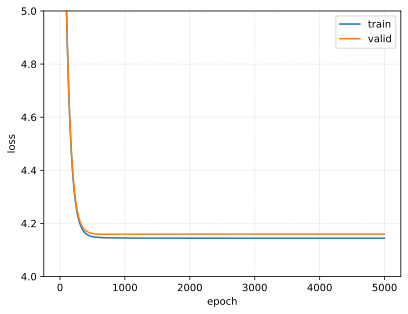

In [21]:
#| code-fold: true
plt.plot(history["train"], label="train")
plt.plot(history["valid_steps"], history["valid"], label="valid")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.ylim(4, 5)
plt.legend()
plt.grid(linestyle="dotted", alpha=0.6)

In [22]:
print("latent:")
print("coverage:", [f"{cov:.4f}" for cov, acc in lf_params])
print("accuracy:", [f"{acc:.4f}" for cov, acc in lf_params])

latent:
coverage: ['0.3000', '0.5000', '0.4000', '0.2000', '0.2500']
accuracy: ['0.7500', '0.6500', '0.7000', '0.8000', '0.9000']


The model recovers the latent LF parameters better when coverage is high. Low-coverage LFs have fewer observed (non-abstain) outputs, making their confusion matrices harder to estimate:

In [23]:
print("estimated confusion matrices (per LF):")
for j in range(len(lf_params)):
    print(f"\nLF{j+1} (latent: cov={lf_params[j][0]:.2f}, acc={lf_params[j][1]:.2f}):")
    C_j = gen_model.C[:, :, j]  # (K, K+1)
    df = pd.DataFrame(
        C_j.numpy(), 
        index=[f"y={k}" for k in range(K)],
        columns=[f"pred={k}" for k in range(K)] + ["abstain"]
    )
    print(df.to_string())

estimated confusion matrices (per LF):

LF1 (latent: cov=0.30, acc=0.75):
       pred=0    pred=1   abstain
y=0  0.201422  0.075835  0.722743
y=1  0.091389  0.217808  0.690803

LF2 (latent: cov=0.50, acc=0.65):
      pred=0    pred=1   abstain
y=0  0.35447  0.147055  0.498475
y=1  0.15723  0.326067  0.516704

LF3 (latent: cov=0.40, acc=0.70):
       pred=0    pred=1   abstain
y=0  0.306935  0.105694  0.587372
y=1  0.098635  0.304471  0.596894

LF4 (latent: cov=0.20, acc=0.80):
       pred=0    pred=1   abstain
y=0  0.162639  0.051900  0.785461
y=1  0.047548  0.149371  0.803081

LF5 (latent: cov=0.25, acc=0.90):
       pred=0    pred=1   abstain
y=0  0.196527  0.047843  0.755630
y=1  0.048755  0.216109  0.735136


The trained model can be used to estimate joint probabilities of LF outputs and targets:

In [24]:
l = torch.tensor([[-1, -1, -1, -1, -1]])
for y in range(K):
    print(f"p(Λ=all_abstain, y={y}): {gen_model.infer_joint_proba(l, y=y).item():.6f}")

p(Λ=all_abstain, y=0): 0.050238
p(Λ=all_abstain, y=1): 0.075470


The conditional probabilities of targets given LF outputs sum to 1:

In [25]:
# Simple test that the model learned (without using latent labels):
l = torch.tensor([[-1, -1, -1, -1, -1]])
for y in range(K):
    print(f"p(y={y} | Λ=all_abstain): {gen_model.target_cond_proba(y, l).item():.4f}")

p(y=0 | Λ=all_abstain): 0.3996
p(y=1 | Λ=all_abstain): 0.6004


### Label inference

Soft labels can be generated for a test input using $p_{\hat{\Phi}}(Y = y \mid \Lambda = \lambda(\textbf{\textsf{x}}))$ calculated using learned LF parameters. This already takes into account the prior label distribution. In particular, if all LFs abstain, then the model falls back to the prior label distribution. Evaluating using latent labels:

In [26]:
from sklearn.metrics import (
    f1_score, 
    confusion_matrix, 
    precision_score, 
    recall_score
)

import warnings
warnings.filterwarnings("ignore")


def evaluate(model, x, y, t=0.5, verbose=True):
    m = x.shape[0]
    preds = model.predict(x) if t is None else model.predict(x, t)
    f1 = f1_score(y.numpy(), preds.numpy(), average="weighted")
    recall = recall_score(y.numpy(), preds.numpy(), average="weighted")
    precision = precision_score(y.numpy(), preds.numpy(), average="weighted")
    
    if verbose:
        print(confusion_matrix(y.numpy(), preds.numpy()))
    
    return {
        "f1": f1,
        "recall": recall,
        "precision": precision,
        "m": m, "message": f"m={m}, f1={f1:.5f}, t={t:.5f}"
    }

print(evaluate(gen_model, x_train, y_train)["message"]); print()
print(evaluate(gen_model, x_valid, y_valid)["message"])

[[1984 1259]
 [ 687 4070]]
m=8000, f1=0.75188, t=0.50000

[[ 477  309]
 [ 202 1012]]
m=2000, f1=0.74056, t=0.50000


### Noise-aware training

Noise-aware training amounts to weighting the loss with the estimate of the generative model for each target ${p_{\hat{\Phi}}(Y = y \mid \Lambda = \lambda(\textbf{\textsf{x}}))} = {p_{\hat{\Phi}}(Y = y,\, \Lambda = \lambda(\textbf{\textsf{x}}))}
\, /\, {p_{\hat{\Phi}}(\Lambda = \lambda(\textbf{\textsf{x}}))}.$ This allows us to train a model without labels:

In [27]:
import torch.nn as nn
from tempfile import NamedTemporaryFile
np.random.seed(42); torch.manual_seed(42)


class NoiseAwareTrainer:
    def __init__(self, clf, gen_model, labeling_funcs: list):
        self.clf = clf
        self.K = gen_model.K
        self.lfs = labeling_funcs
        self.gen_model = gen_model

    def loss_fn(self, L, x):
        with torch.no_grad():
            # p(y | Λ) for each class
            cond_probs = [self.gen_model.target_cond_proba(y, L) for y in range(self.K)]
        
        fx = self.clf(x).view(-1)   # logit for class 1
        # Binary cross-entropy weighted by soft labels
        # loss = -sum_y p(y|Λ) * [y*log(σ(fx)) + (1-y)*log(1-σ(fx))]
        # = p(y=0|Λ) * log(1+exp(fx)) + p(y=1|Λ) * log(1+exp(-fx))
        loss_0 = torch.log(1 + torch.exp(fx)) * cond_probs[0]     # cost when y=0
        loss_1 = torch.log(1 + torch.exp(-fx)) * cond_probs[1]    # cost when y=1
        return (loss_0 + loss_1).mean()

    def run(self, x_train, x_valid=None, epochs=10, bs=8, lr=0.001, alpha=0.0, momentum=0.1):
        m = x_train.shape[0]
        history = {"train": [], "valid": [], "valid_steps": []}
        best_loss = np.inf
        best_epoch = 0
        optim = torch.optim.SGD(self.clf.parameters(), lr=lr, weight_decay=alpha, momentum=momentum)
        tmp = NamedTemporaryFile(suffix=".pt", delete=True)
        L_train = self.lf_outputs(x_train)
        L_valid = self.lf_outputs(x_valid) if x_valid is not None else None

        try: 
            for epoch in tqdm(range(epochs)):
                B = torch.randperm(m)
                for i in range(m // bs):
                    batch = B[i * bs: (i + 1) * bs]
                    loss = self.loss_fn(L_train[batch], x_train[batch])

                    # gradient step
                    loss.backward()
                    optim.step()
                    optim.zero_grad()

                    # callbacks
                    history["train"].append(loss.item())
                            
                    del loss
                    torch.cuda.empty_cache()
                
                with torch.no_grad():
                    if x_valid is not None:
                        val_loss = self.loss_fn(L_valid, x_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append((epoch + 1) * (m // bs))
                        if val_loss < best_loss:
                            best_loss = val_loss.item()
                            best_epoch = epoch
                            torch.save(self.clf.state_dict(), tmp.name)

                if epoch - best_epoch > int(0.05 * epochs):
                    print(f"Early stopping at epoch {epoch}...")
                    raise KeyboardInterrupt

        except KeyboardInterrupt:
            print("Training stopped.")

        finally:
            print(f"Best valid loss: {best_loss}")
            self.clf.load_state_dict(torch.load(tmp.name, weights_only=True))
            return history
    
    def lf_outputs(self, x):
        L = torch.stack([lf(x) for lf in self.lfs], dim=1).long()
        return L

    @torch.no_grad()
    def predict_proba(self, x):
        s = self.clf(x).view(-1)
        return 1 / (1 + torch.exp(-s))

    @torch.no_grad()
    def predict(self, x, t=0.5):
        p = self.predict_proba(x)
        return (p >= t).long()


clf = nn.Sequential(nn.Linear(2, 8), nn.SELU(), nn.Linear(8, 1))
trainer = NoiseAwareTrainer(clf, gen_model, labeling_funcs=labeling_funcs)
history = trainer.run(x_train, x_valid, epochs=120, bs=32, lr=0.003, alpha=0.0, momentum=0.1)


  0%|          | 0/120 [00:00<?, ?it/s]


  1%|          | 1/120 [00:00<00:31,  3.79it/s]


  2%|▏         | 2/120 [00:00<00:21,  5.41it/s]


  2%|▎         | 3/120 [00:00<00:18,  6.47it/s]


  3%|▎         | 4/120 [00:00<00:16,  7.14it/s]

...


 98%|█████████▊| 118/120 [00:15<00:00,  8.37it/s]


 99%|█████████▉| 119/120 [00:15<00:00,  8.42it/s]


100%|██████████| 120/120 [00:15<00:00,  8.45it/s]


100%|██████████| 120/120 [00:15<00:00,  7.77it/s]

Best valid loss: 0.668989360332489


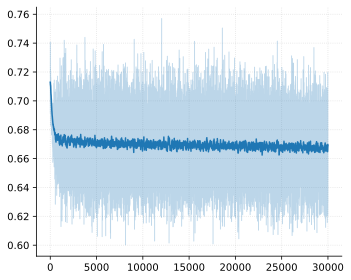

In [28]:
#| code-fold: true
from notebooks.plot import Plot

p = Plot()
p[0].line(history["train"], color="C0", label="train", smooth=100)
p.show()

# plt.figure(figsize=(5, 3))
# plt.plot(history["train"], label="train")
# plt.plot(history["valid_steps"], history["valid"], label="valid")
# plt.ylabel("loss")
# plt.xlabel("step")
# plt.legend()
# plt.grid(linestyle="dotted", alpha=0.6);

In [29]:
print(evaluate(trainer, x_train, y_train, t=0.5)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, t=0.5)["message"])

[[   0 3243]
 [   0 4757]]
m=8000, f1=0.44346, t=0.50000

[[   0  786]
 [   0 1214]]
m=2000, f1=0.45856, t=0.50000


There are two ways to improve the threshold `t` (both not free, i.e. requires some assumptions):

**1. Matching the label prior distribution.** The threshold for predicting hard labels can be calibrated by using the prior label distribution. This significantly improves F1. Here we use the entirety of our data (i.e. `x`):

In [30]:
from collections import Counter

calibration_score = []  # lower = better
thresholds = np.linspace(0, 1, num=500)
for t in thresholds:
    c = Counter(trainer.predict(x, t).tolist())
    n = len(x)
    c[0] = c.get(0, 1) / n 
    c[1] = c.get(1, 1) / n 
    calibration_score.append(-LABEL_PROBS[0] * np.log(c[0]) + -LABEL_PROBS[1] * np.log(c[1]))


t_best = thresholds[np.argmin(calibration_score)]
print(evaluate(trainer, x_train, y_train, t=t_best)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, t=t_best)["message"])

[[2635  608]
 [ 653 4104]]
m=8000, f1=0.84254, t=0.59118

[[ 626  160]
 [ 143 1071]]
m=2000, f1=0.84820, t=0.59118


:::{.callout-note }
This calibration uses the **entire** dataset `x` (both train and valid) and assumes exact [knowledge of the class prior]{.mark} `LABEL_PROBS`. The cross-entropy objective selects the threshold $t$ whose predicted label distribution best matches the prior. If the prior estimate is inaccurate, the selected [decision threshold]{.underline} shifts accordingly: overestimating $p(y=1)$ pushes $t$ lower (more positive predictions), while underestimating it pushes $t$ higher. In practice, the class prior is rarely known exactly, so this approach is sensitive to estimation error &mdash; especially for imbalanced problems.
:::

**2. Tuning on a labeled subset.** If a representative subset of the data is labeled, even if small, then we can use that to tune the threshold. The following iteratively finds the threshold that maximizes weighted F1 on the validation set:

[[3100  143]
 [ 832 3925]]
m=8000, f1=0.87922, t=0.59359

[[560  30]
 [142 768]]
m=1500, f1=0.88654, t=0.59359


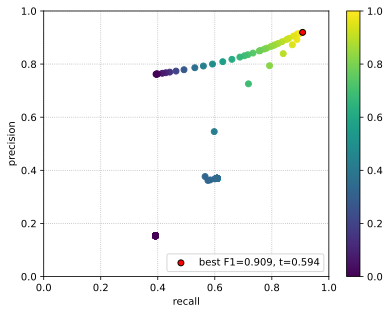

In [31]:
def pr_curve(model, x, y, num_thresholds, min_t=0.0, max_t=1.0):
    p, r, t, f = [], [], [], []
    for threshold in np.linspace(min_t, max_t, num_thresholds):
        preds = model.predict(x, threshold).numpy()
        f.append(f1_score(y.numpy(), preds, average="weighted"))
        r.append(recall_score(y.numpy(), preds, average="weighted"))
        p.append(precision_score(y.numpy(), preds, average="weighted"))
        t.append(threshold)
    
    return p, r, t, f

def plot_pr_curve(model, x, y, num_thresholds=200, min_t=0.0, max_t=1.0):
    """Tune threshold based on validation set."""
    p, r, t, f = pr_curve(model, x, y, num_thresholds, min_t, max_t);
    t_best_idx = np.argmax(f)
    t_best = t[t_best_idx]

    # plotting the sample F1s
    plt.grid(linestyle="dotted", zorder=0)
    plt.scatter(r, p, c=f, zorder=2)
    plt.scatter(x=r[t_best_idx], y=p[t_best_idx], edgecolor="k", facecolor="red", label=f"best F1={f[t_best_idx]:.3f}, t={t_best:.3f}", zorder=3)
    plt.colorbar()
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend(loc="lower right")

    return t_best


# Tuning the threshold on a labeled subset (here 500 pts)
t_best = plot_pr_curve(trainer, x_valid[:500], y_valid[:500], num_thresholds=1000, min_t=0.0, max_t=1.0)
print(evaluate(trainer, x_train, y_train, t=t_best)["message"]); print()
print(evaluate(trainer, x_valid[500:], y_valid[500:], t=t_best)["message"])

**Remark.** With threshold calibration, the noise-aware model achieves F1 $\approx 0.85$ on training data and $\approx 0.89$ on the labeled validation split &mdash; a substantial improvement over the generative model's F1 $\approx 0.75.$ This demonstrates that the discriminative model learns decision boundaries beyond what the LFs alone can express.

---

## Application: IMDB Movie Reviews

We apply the same weak supervision pipeline to a real text classification task: **IMDB movie review sentiment analysis**. The key challenge is adapting our `GenModel` and `NoiseAwareTrainer` (designed for tensor inputs) to work with raw text data. We define text-based labeling functions that detect sentiment patterns, wrap them to be tensor-compatible, and use TF-IDF features to train the noise-aware discriminative model.

In [32]:
import re
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# Load IMDB dataset (3000 train, 1000 valid)
ds = load_dataset("imdb")
train_ds = ds["train"].shuffle(seed=RANDOM_SEED).select(range(3000))
valid_ds = ds["test"].shuffle(seed=RANDOM_SEED).select(range(1000))

train_texts = train_ds["text"]
valid_texts = valid_ds["text"]
y_train_imdb = torch.tensor(train_ds["label"])    # {0, 1}
y_valid_imdb = torch.tensor(valid_ds["label"])

K = 2
ABSTAIN = K


# (1) Strong adjectives
def lf_strong_sentiment(text):
    text = text.lower()
    pos_words = ["excellent", "masterpiece", "outstanding", "brilliant", "perfect", "superb", "fantastic", "wonderful"]
    neg_words = ["terrible", "awful", "horrible", "worst", "dreadful", "atrocious", "abysmal", "pathetic"]
    pos = any(w in text for w in pos_words)
    neg = any(w in text for w in neg_words)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (2) Balance of positive/negative word counts
def lf_sentiment_words(text):
    text = text.lower()
    pos_words = ["great", "love", "amazing", "best", "enjoyed", "favorite", "fun"]
    neg_words = ["bad", "waste", "boring", "poor", "stupid", "annoying", "disappointing"]
    pos_count = sum(1 for w in pos_words if w in text)
    neg_count = sum(1 for w in neg_words if w in text)
    if pos_count > neg_count: return 1
    if neg_count > pos_count: return 0
    return ABSTAIN


# (3) Explicit ratings (e.g. "10/10", "1 star")
def lf_rating_mention(text):
    text = text.lower()
    pos_patterns = [r"10/10", r"10 out of 10", r"5 stars", r"5/5"]
    neg_patterns = [r"1/10", r"1 out of 10", r"1 star[^s]", r"0 stars", r"0/10"]
    pos = any(re.search(p, text) for p in pos_patterns)
    neg = any(re.search(p, text) for p in neg_patterns)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (4) Re-watch / walk-out behavior
def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "seen it multiple times", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish", "wasted 2 hours"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (5) Negative comparative phrases
def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower or "disappointing compared" in text_lower:
        return 0
    return ABSTAIN


# (6) Recommendation / avoidance phrases
def lf_recommendation(text):
    text = text.lower()
    pos_phrases = ["highly recommend", "must see", "must watch", "worth watching", "go see", "definitely watch", "check it out"]
    neg_phrases = ["do not recommend", "don't recommend", "avoid", "skip this", "don't bother", "don't waste", "stay away", "save your"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


# (7) Exclamation + sentiment phrases
def lf_exclamation_sentiment(text):
    if "!" not in text: return ABSTAIN
    text = text.lower()
    pos_phrases = ["loved it", "great film", "great movie", "must see", "highly recommended", "well done"]
    neg_phrases = ["waste of time", "don't watch", "stay away", "save your money", "never again", "so bad"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return 1
    if neg and not pos: return 0
    return ABSTAIN


text_lfs_raw = [
    lf_strong_sentiment,
    lf_sentiment_words,
    lf_rating_mention,
    lf_viewing_experience,
    lf_comparative_sentiment,
    lf_recommendation,
    lf_exclamation_sentiment,
]

# Coverage and accuracy on train set
stats = []
for lf in text_lfs_raw:
    outputs = [lf(t) for t in train_texts]
    labels = y_train_imdb.numpy()
    fired = [i for i, o in enumerate(outputs) if o != ABSTAIN]
    cov = len(fired) / len(outputs)
    acc = sum(1 for i in fired if outputs[i] == labels[i]) / max(len(fired), 1)
    stats.append({
        "LF": lf.__name__,
        "coverage": f"{cov:.3f}",
        "accuracy": f"{acc:.3f}",
    })

pd.DataFrame(stats)

,LF,coverage,accuracy
0,lf_strong_sentiment,0.414,0.881
1,lf_sentiment_words,0.691,0.756
2,lf_rating_mention,0.023,0.812
3,lf_viewing_experience,0.011,0.812
4,lf_comparative_sentiment,0.013,0.800
5,lf_recommendation,0.112,0.798
6,lf_exclamation_sentiment,0.051,0.810


**Adapting text LFs.** Our `GenModel` and `NoiseAwareTrainer` call `lf(x)` where `x` is a tensor. To bridge this gap, we precompute LF outputs for all texts and wrap them in a `TextLF` class &mdash; the same caching pattern used by `CachedLF` in the synthetic experiments. We also extract TF-IDF features as the input representation for the discriminative model:

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer


class TextLF:
    """Wraps a text LF for tensor-based GenModel/NoiseAwareTrainer."""

    def __init__(self, lf_func, texts_train, texts_valid):
        self._cache = {
            len(texts_train): torch.tensor([lf_func(t) for t in texts_train]),
            len(texts_valid): torch.tensor([lf_func(t) for t in texts_valid]),
        }

    def __call__(self, x):
        return self._cache[x.shape[0]]  # (1)


text_lfs = [TextLF(lf, train_texts, valid_texts) for lf in text_lfs_raw]

vectorizer = TfidfVectorizer(max_features=5000)
x_train_imdb = torch.tensor(
    vectorizer.fit_transform(train_texts).toarray(), dtype=torch.float32
)
x_valid_imdb = torch.tensor(
    vectorizer.transform(valid_texts).toarray(), dtype=torch.float32
)

print(f"x_train: {x_train_imdb.shape}")
print(f"x_valid: {x_valid_imdb.shape}")

x_train: torch.Size([3000, 5000])
x_valid: torch.Size([1000, 5000])


**Generative model.** We train `GenModel` on the text LF outputs with a balanced prior. The model learns the latent coverage and accuracy of each LF, and produces soft labels $p_{\hat{\Phi}}(Y = y \mid \Lambda = \lambda(\textbf{\textsf{x}}_i))$ for every review:

In [34]:
IMDB_LABEL_PROBS = [0.50, 0.50]

gen_model_imdb = GenModel(text_lfs, num_classes=2, class_prior=IMDB_LABEL_PROBS)
history_gen_imdb = gen_model_imdb.fit(
    x_train_imdb, x_valid_imdb,
    epochs=5000, lr=0.01,
)


  0%|          | 0/5000 [00:00<?, ?it/s]


  1%|          | 59/5000 [00:00<00:08, 586.83it/s]


  2%|▏         | 124/5000 [00:00<00:07, 620.94it/s]


  4%|▎         | 187/5000 [00:00<00:08, 572.88it/s]


  5%|▍         | 245/5000 [00:00<00:08, 543.97it/s]

...


 97%|█████████▋| 4854/5000 [00:10<00:00, 514.20it/s]


 98%|█████████▊| 4906/5000 [00:10<00:00, 452.73it/s]


 99%|█████████▉| 4953/5000 [00:10<00:00, 442.14it/s]


100%|█████████▉| 4999/5000 [00:10<00:00, 435.11it/s]


100%|██████████| 5000/5000 [00:10<00:00, 479.27it/s]

Training and validation NLL for the generative model:

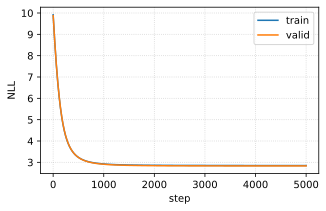

In [35]:
#| code-fold: true
plt.figure(figsize=(5, 3))
plt.plot(history_gen_imdb["train"], label="train")
plt.plot(history_gen_imdb["valid_steps"], history_gen_imdb["valid"], label="valid")
plt.legend()
plt.xlabel("step")
plt.ylabel("NLL")
plt.grid(linestyle="dotted", alpha=0.6);

**Noise-aware training.** We train an MLP on TF-IDF features using the noise-aware loss, weighted by the generative model's soft labels. The discriminative model can generalize beyond the keywords used in the LFs by leveraging the full TF-IDF vocabulary:

In [36]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_imdb = nn.Sequential(nn.Linear(5000, 32), nn.SELU(), nn.Linear(32, 1))
trainer_imdb = NoiseAwareTrainer(clf_imdb, gen_model_imdb, text_lfs)
history_nat_imdb = trainer_imdb.run(
    x_train_imdb, x_valid_imdb,
    epochs=300, bs=64, lr=0.003, alpha=0.0, momentum=0.9,
)


  0%|          | 0/300 [00:00<?, ?it/s]


  0%|          | 1/300 [00:00<00:39,  7.55it/s]


  1%|          | 3/300 [00:00<00:29, 10.08it/s]


  2%|▏         | 5/300 [00:00<00:27, 10.75it/s]


  2%|▏         | 7/300 [00:00<00:26, 11.05it/s]

...


 72%|███████▏  | 217/300 [00:21<00:08, 10.22it/s]


 73%|███████▎  | 219/300 [00:21<00:07, 10.26it/s]


 74%|███████▎  | 221/300 [00:21<00:07, 10.29it/s]


 74%|███████▍  | 222/300 [00:22<00:07, 10.07it/s]

Early stopping at epoch 222...
Training stopped.
Best valid loss: 0.5066542625427246


Training and validation loss for the noise-aware discriminative model:

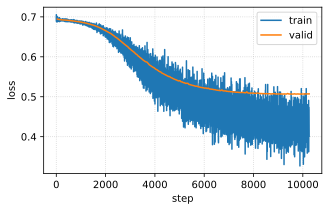

In [37]:
#| code-fold: true
plt.figure(figsize=(5, 3))
plt.plot(history_nat_imdb["train"], label="train")
plt.plot(history_nat_imdb["valid_steps"], history_nat_imdb["valid"], label="valid")
plt.legend()
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(linestyle="dotted", alpha=0.6);

**Evaluation.** We compare the generative model (LF outputs only) with the noise-aware discriminative model (TF-IDF features), and apply the same prior-based threshold calibration from the synthetic experiments:

In [38]:
print("GenModel (IMDB):")
print(evaluate(gen_model_imdb, x_train_imdb, y_train_imdb, t=0.5)["message"]); print()
print(evaluate(gen_model_imdb, x_valid_imdb, y_valid_imdb, t=0.5)["message"])

print("\nNoiseAwareTrainer (IMDB):")
print(evaluate(trainer_imdb, x_train_imdb, y_train_imdb, t=0.5)["message"]); print()
print(evaluate(trainer_imdb, x_valid_imdb, y_valid_imdb, t=0.5)["message"])

# Threshold calibration using label prior
calibration_score = []
thresholds = np.linspace(0, 1, num=500)
for t in thresholds:
    c = Counter(trainer_imdb.predict(x_train_imdb, t).tolist())
    n = len(x_train_imdb)
    c[0] = c.get(0, 1) / n
    c[1] = c.get(1, 1) / n
    calibration_score.append(-IMDB_LABEL_PROBS[0] * np.log(c[0]) + -IMDB_LABEL_PROBS[1] * np.log(c[1]))

t_best_imdb = thresholds[np.argmin(calibration_score)]
print(f"\nCalibrated NoiseAwareTrainer (IMDB, t={t_best_imdb:.4f}):")
print(evaluate(trainer_imdb, x_train_imdb, y_train_imdb, t=t_best_imdb)["message"]); print()
print(evaluate(trainer_imdb, x_valid_imdb, y_valid_imdb, t=t_best_imdb)["message"])

GenModel (IMDB):
[[1194  314]
 [ 365 1127]]
m=3000, f1=0.77358, t=0.50000

[[406 101]
 [129 364]]
m=1000, f1=0.76973, t=0.50000

NoiseAwareTrainer (IMDB):
[[1141  367]
 [ 224 1268]]
m=3000, f1=0.80260, t=0.50000

[[402 105]
 [ 81 412]]
m=1000, f1=0.81396, t=0.50000



Calibrated NoiseAwareTrainer (IMDB, t=0.5611):
[[1205  303]
 [ 294 1198]]
m=3000, f1=0.80100, t=0.56112

[[436  71]
 [116 377]]
m=1000, f1=0.81250, t=0.56112


:::{.callout-note }
The noise-aware model outperforms the generative model on IMDB reviews. While the generative model can only make predictions based on the [7 labeling function outputs]{.mark} (at most $3^7 = 2187$ unique patterns), the discriminative model leverages [5000 TF-IDF features]{.mark} to capture sentiment signals beyond the keywords hardcoded in our LFs. Threshold calibration provides a small additional lift by aligning the predicted label distribution with the prior. This demonstrates the core value of the data programming pipeline: noisy LFs provide initial supervision, and the discriminative model generalizes from there.
:::

---